# Registers for RTX 6000 Ada

Code: fill regs via global loads to local arrays -> spin until premept -> repeat. Weird printf trick. reg.cu

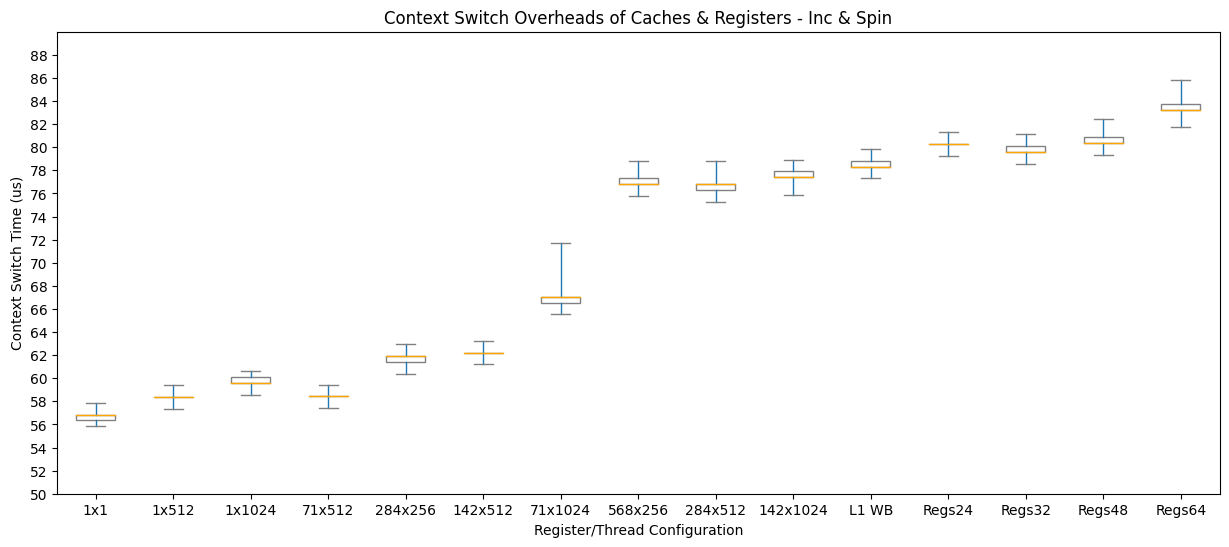

In [1]:
from analyzer_functions import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

TIMESLICE_LENGTH = 2131

def multi_boxplot2(df, title, ymin=None, ymax=None, tick_step=1):
	plt.figure(figsize=(15, 6))
	df.boxplot(grid=False, 
           patch_artist=True,
           boxprops=dict(facecolor='none', color='gray'),
           flierprops=dict(markerfacecolor='red', marker='o', markersize=5),
           medianprops=dict(color='orange', linewidth=1),
		   capprops=dict(color='gray', linewidth=1),
		   whis=[0,100])
	plt.title(title)
	plt.xlabel('Register/Thread Configuration')
	plt.ylabel('Context Switch Time (us)')

	# y ticks
	if ymin is None:
		ymin = np.floor(df.min().min()) - 10
	if ymax is None:
		ymax = np.ceil(df.max().max()) + 10
	plt.ylim(ymin, ymax)
	plt.yticks(np.arange(ymin, ymax, tick_step))
	LABEL_STEP = 5
	plt.gca().set_yticks(np.arange(ymin, ymax, tick_step).tolist())
	plt.gca().set_yticklabels(np.arange(ymin, ymax, tick_step).tolist())
	# Show minor ticks (for tick marks every 1 unit)
	#plt.gca().tick_params(axis='y', which='both', length=8, width=tick_step)
	# Show minor ticks and adjust their appearance
	#plt.gca().tick_params(axis='y', which='minor', length=4, width=tick_step)
	# Add minor ticks at every unit
	#plt.gca().minorticks_on()
	# Disable minor ticks on the x-axis
	#plt.gca().tick_params(axis='x', which='minor', length=0)
	plt.show()

dir = 'l2/L1andL2'
# while(1)
while1_ivls = read_ivls('data/'+dir+'/ada-while1x1-10k.csv', single=True)
while1 = get_overhead(while1_ivls, TIMESLICE_LENGTH)
while142x1024_ivls = read_ivls('data/'+dir+'/ada-while142x1024-10k.csv', single=True)
while142x1024 = get_overhead(while142x1024_ivls, TIMESLICE_LENGTH)

# L2 spin
l2spin1x1_ivls = read_ivls('data/l2spin/ada-l2spin-1x1-10k.csv', single=True)
l2spin142x512_ivls = read_ivls('data/l2spin/ada-l2spin-142x512-10k.csv', single=True)
l2spin71x512_ivls = read_ivls('data/l2spin/ada-l2spin-71x512-10k.csv', single=True)
l2spin71x1024_ivls = read_ivls('data/l2spin/ada-l2spin-71x1024-10k.csv', single=True)
l2spin142x1024_ivls = read_ivls('data/l2spin/ada-l2spin-142x1024-10k.csv', single=True)
l2spin1x512_ivls = read_ivls('data/l2spin/ada-l2spin-1x512-10k.csv', single=True)
l2spin1x1024_ivls = read_ivls('data/l2spin/ada-l2spin-1x1024-10k.csv', single=True)
l2spin284x512_ivls = read_ivls('data/l2spin/ada-l2spin-284x512-10k.csv', single=True)
l2spin568x256_ivls = read_ivls('data/l2spin/ada-l2spin-568x256-10k.csv', single=True)
l2spin284x256_ivls = read_ivls('data/l2spin/ada-l2spin-284x256-10k.csv', single=True)

# L1/L2 mem
l1_cg_ivls = read_ivls('data/'+dir+'/ada-l1cg-10k.csv', single=True)
l1_wb_ivls = read_ivls('data/'+dir+'/ada-l1wb-10k.csv', single=True)
l1_wt_ivls = read_ivls('data/'+dir+'/ada-l1wt-10k.csv', single=True)
l2_cg_ivls = read_ivls('data/'+dir+'/ada-l2cg-10k.csv', single=True)
l2_wb_ivls = read_ivls('data/'+dir+'/ada-l2wb-10k.csv', single=True)
l2_wt_ivls = read_ivls('data/'+dir+'/ada-l2wt-10k.csv', single=True)

# L2 spin
l2_spin1x1 = get_overhead(l2spin1x1_ivls, TIMESLICE_LENGTH)
l2_spin142x512 = get_overhead(l2spin142x512_ivls, TIMESLICE_LENGTH)
l2spin71x512 = get_overhead(l2spin71x512_ivls, TIMESLICE_LENGTH)
l2spin71x1024 = get_overhead(l2spin71x1024_ivls, TIMESLICE_LENGTH)
l2_spin142x1024 = get_overhead(l2spin142x1024_ivls, TIMESLICE_LENGTH)
l2_spin1x512 = get_overhead(l2spin1x512_ivls, TIMESLICE_LENGTH)
l2_spin1x1024 = get_overhead(l2spin1x1024_ivls, TIMESLICE_LENGTH)
l2spin284x512 = get_overhead(l2spin284x512_ivls, TIMESLICE_LENGTH)
l2spin568x256 = get_overhead(l2spin568x256_ivls, TIMESLICE_LENGTH)
l2spin284x256 = get_overhead(l2spin284x256_ivls, TIMESLICE_LENGTH)

# L1/L2 mem
l1_cg = get_overhead(l1_cg_ivls, TIMESLICE_LENGTH)
l1_wb = get_overhead(l1_wb_ivls, TIMESLICE_LENGTH)
l1_wt = get_overhead(l1_wt_ivls, TIMESLICE_LENGTH)
l2_cg = get_overhead(l2_cg_ivls, TIMESLICE_LENGTH)
l2_wb = get_overhead(l2_wb_ivls, TIMESLICE_LENGTH)
l2_wt = get_overhead(l2_wt_ivls, TIMESLICE_LENGTH)

# register data
regs24_ivls = read_ivls('data/registers/ada-regs24-142x1024-10k.csv', single=True)
regs32_ivls = read_ivls('data/registers/ada-regs32-142x1024-10k.csv', single=True)
regs48_ivls = read_ivls('data/registers/ada-regs48-142x1024-10k.csv', single=True)
regs64_ivls = read_ivls('data/registers/ada-regs64-142x1024-10k.csv', single=True)
regs24 = get_overhead(regs24_ivls, TIMESLICE_LENGTH)
regs32 = get_overhead(regs32_ivls, TIMESLICE_LENGTH)
regs48 = get_overhead(regs48_ivls, TIMESLICE_LENGTH)
regs64 = get_overhead(regs64_ivls, TIMESLICE_LENGTH)


data = {
	#'While1x1': while1,
	#'While142x1024': while1,
	'1x1': l2_spin1x1,
	'1x512': l2_spin1x512,
	'1x1024': l2_spin1x1024,
	'71x512': l2spin71x512,
	'284x256': l2spin284x256,
	'142x512': l2_spin142x512,
	'71x1024': l2spin71x1024,
	'568x256': l2spin568x256,
	'284x512': l2spin284x512,
	'142x1024': l2_spin142x1024,
	'L1 WB': l1_wb,
	'Regs24': regs24,
	'Regs32': regs32,
	'Regs48': regs48,
	'Regs64': regs64
}

def plot_dir2(title, data, lower=30, upper=150, tick_step=1):
	df = pd.DataFrame(data)
	multi_boxplot(df, 'Context Switch Overheads of Caches & Registers - '+title, lower, upper, tick_step=tick_step)

plot_dir2('Inc & Spin', data, lower=50, upper=90, tick_step=2)

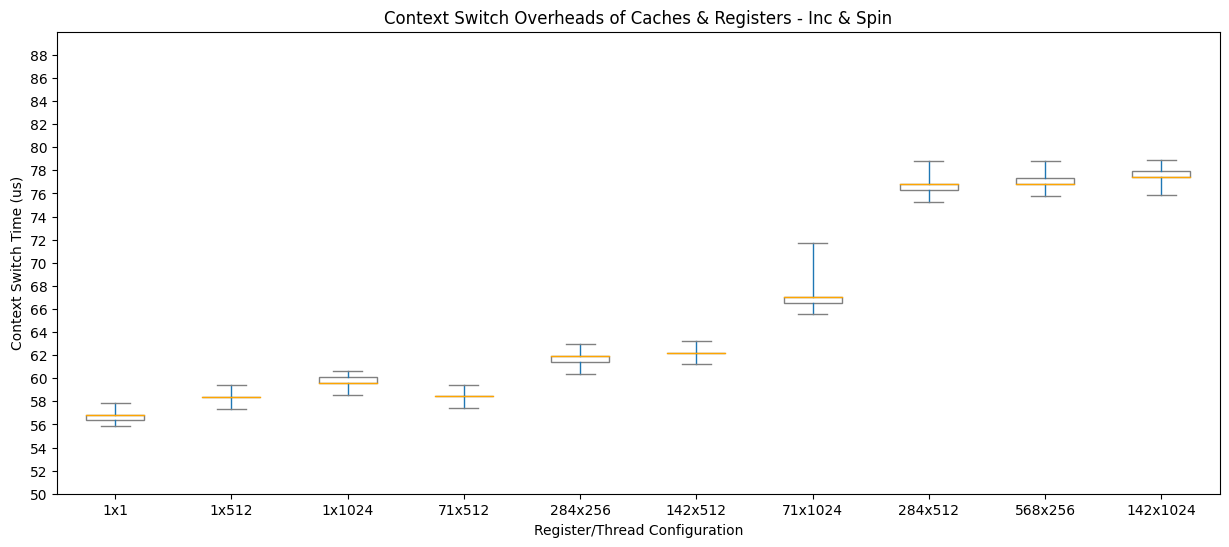

In [11]:
data = {
	'1x1': l2_spin1x1,
	'1x512': l2_spin1x512,
	'1x1024': l2_spin1x1024,
	'71x512': l2spin71x512,
	'284x256': l2spin284x256,
	'142x512': l2_spin142x512,
	'71x1024': l2spin71x1024,
	'284x512': l2spin284x512,
	'568x256': l2spin568x256,
	'142x1024': l2_spin142x1024,
}
plot_dir2('Inc & Spin', data, lower=50, upper=90, tick_step=2)

In [12]:
ohs = get_oh_dir('data/l2spin')

path: data/l2spin/aada-l2spin-1x1-10k.csv
key: 1x1
path: data/l2spin/bada-l2spin-1x512-10k.csv
key: 1x512
path: data/l2spin/cada-l2spin-1x1024-10k.csv
key: 1x1024
path: data/l2spin/dada-l2spin-71x512-10k.csv
key: 71x512
path: data/l2spin/eada-l2spin-256x256-10k.csv
key: 256x256
path: data/l2spin/fada-l2spin-284x256-10k.csv
key: 284x256
path: data/l2spin/gada-l2spin-142x512-10k.csv
key: 142x512
path: data/l2spin/hada-l2spin-71x1024-10k.csv
key: 71x1024
path: data/l2spin/iada-l2spin-284x512-10k.csv
key: 284x512
path: data/l2spin/jada-l2spin-568x256-10k.csv
key: 568x256
path: data/l2spin/kada-l2spin-142x1024-10k.csv
key: 142x1024


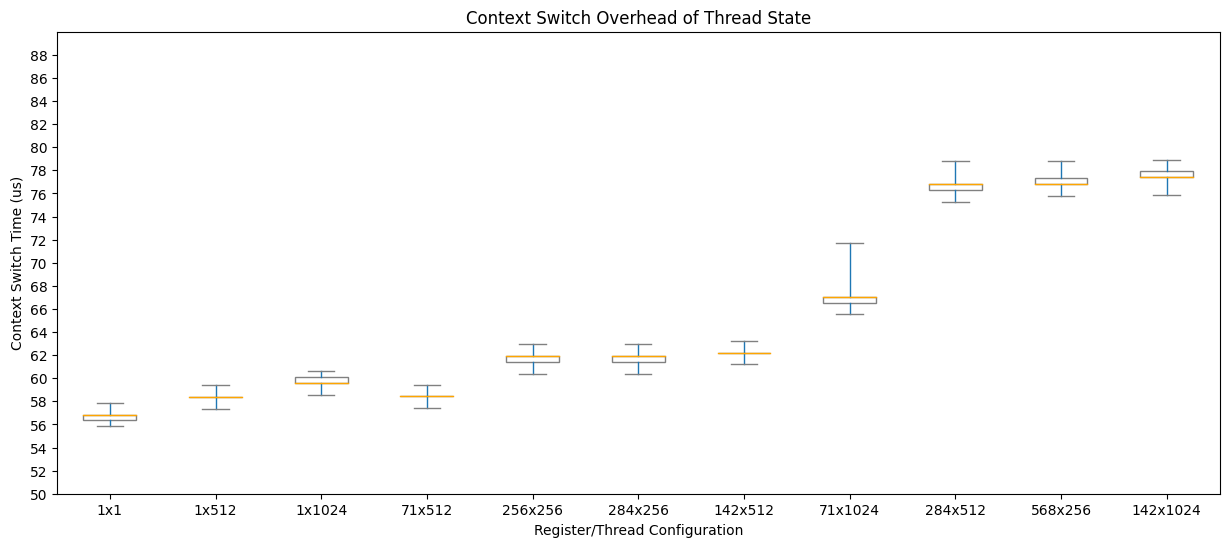

In [10]:
multi_boxplot(ohs, "Context Switch Overhead of Thread State", ymin=50, ymax=90, tick_step=2)